In [66]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
from pmdarima import auto_arima, ARIMA, model_selection
from sklearn.model_selection import ParameterGrid

In [3]:
df = pd.read_csv('../ARIMA,SARIMA,SARIMAX/daily_revenue.csv',index_col = 'date', parse_dates = True, dayfirst = True)
df.head()

,revenue,discount_rate,coupon_rate
date,,,
2018-01-01,"6,270,839",34.27%,1.09%
2018-01-02,"8,922,076",30.87%,1.08%
2018-01-03,"8,446,101",28.11%,1.01%
2018-01-04,"7,785,798",27.32%,0.96%
2018-01-05,"6,375,303",25.70%,0.90%


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   revenue        1795 non-null   object
 1   discount_rate  1795 non-null   object
 2   coupon_rate    1795 non-null   object
dtypes: object(3)
memory usage: 56.1+ KB


In [5]:
# Transform revenue into a float
df['revenue'] = df['revenue'].str.replace(',', '').astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   revenue        1795 non-null   float64
 1   discount_rate  1795 non-null   object 
 2   coupon_rate    1795 non-null   object 
dtypes: float64(1), object(2)
memory usage: 56.1+ KB


In [6]:
# Setting the frequence
df = df.asfreq('D')

In [8]:
# change the time series vairable name
df.rename(columns = {'revenue':'y'}, inplace = True)
df.head()

,y,discount_rate,coupon_rate
date,,,
2018-01-01,6270839.0,34.27%,1.09%
2018-01-02,8922076.0,30.87%,1.08%
2018-01-03,8446101.0,28.11%,1.01%
2018-01-04,7785798.0,27.32%,0.96%
2018-01-05,6375303.0,25.70%,0.90%


# EDA

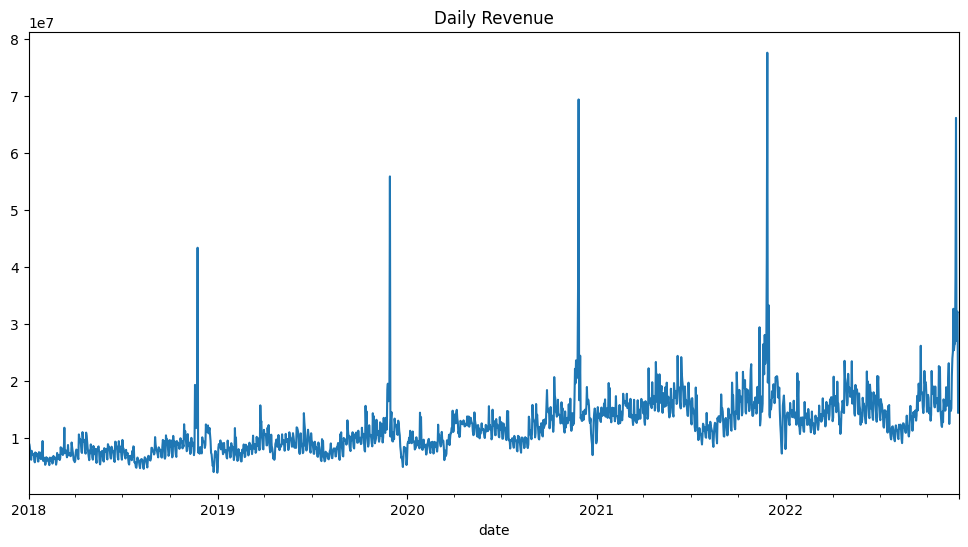

In [10]:
# Daily revenue plot
df['y'].plot(figsize = (12,6))
plt.title('Daily Revenue')
plt.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_28108\3885018770.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df['y'].resample('M').mean(), ylabel='Revenue')


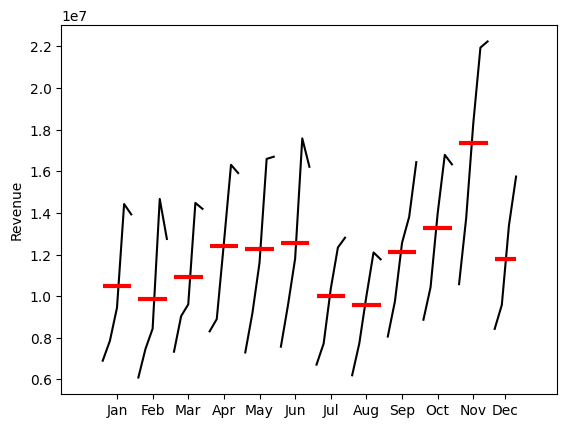

In [14]:
# Plot the monthly seasonality
month_plot(df['y'].resample('M').mean(), ylabel='Revenue')
plt.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_28108\3349294975.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['y'].resample('Q').mean(), ylabel='Revenue')


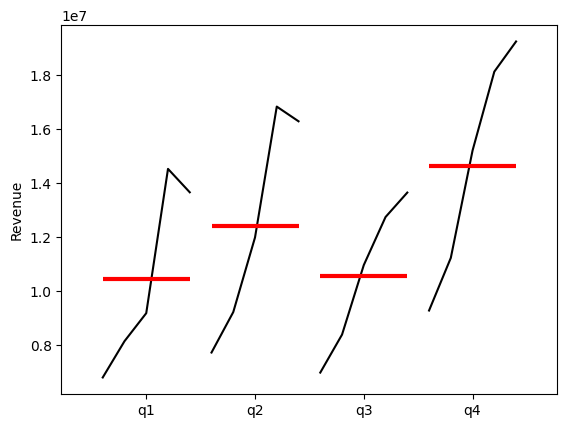

In [15]:
# plotting the quarterly seasonality
quarter_plot(df['y'].resample('Q').mean(), ylabel='Revenue')
plt.show()

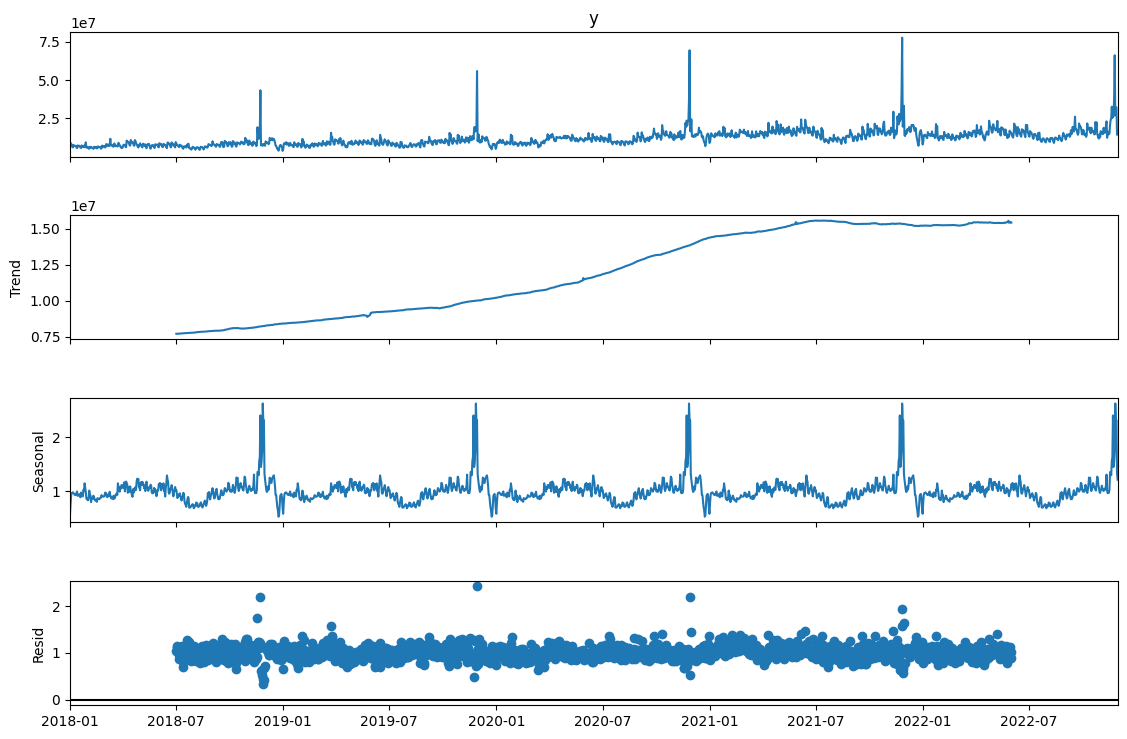

In [17]:
# seasonal decomposition
decomposition = seasonal_decompose(df['y'], model = 'multiplicative', period = 365)
fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

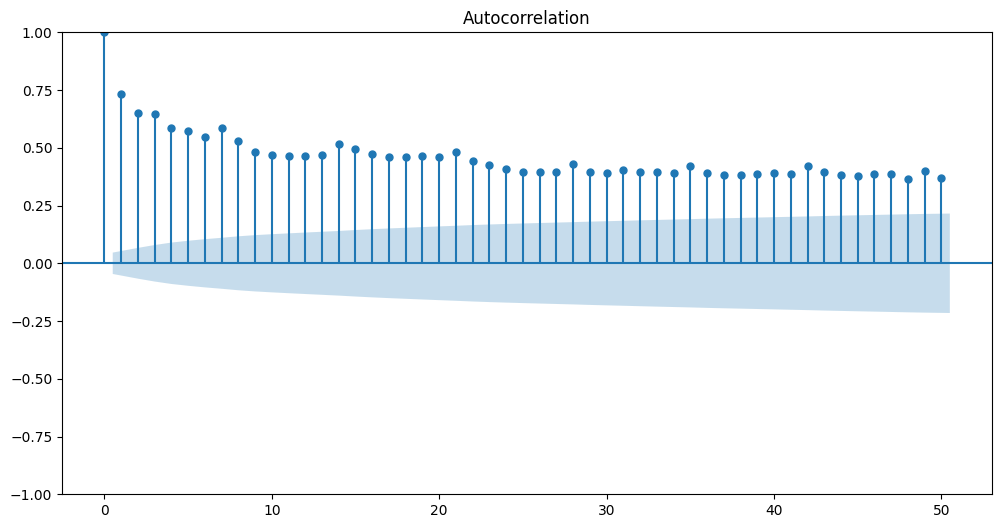

In [18]:
# Plot the auto correlation
fig, ax = plt.subplots(figsize = (12,6))
plot_acf(df['y'], lags = 50, ax = ax)
plt.show()

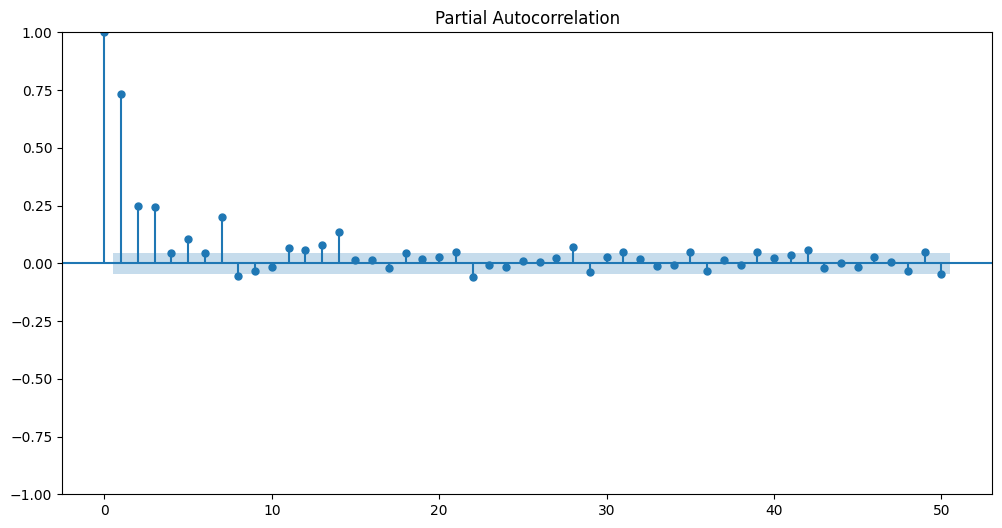

In [19]:
# Plot the partial auto correlation
fig, ax = plt.subplots(figsize = (12,6))
plot_pacf(df['y'], lags = 50, ax = ax)
plt.show()

# Stationarity

In [20]:
# Perform ADF test
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['y'])

print('p-value: %f' % result[1])

# Interpreting the ADF test results
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

p-value: 0.101904
The time series is non-stationary.


In [22]:
# Difference the time series
df['y_diff'] = df.y.diff().dropna()
df['y_diff']

date
2018-01-01           NaN
2018-01-02     2651237.0
2018-01-03     -475975.0
2018-01-04     -660303.0
2018-01-05    -1410495.0
                 ...    
2022-11-26   -39180777.0
2022-11-27     4955921.0
2022-11-28      210050.0
2022-11-29   -17786305.0
2022-11-30      712049.0
Freq: D, Name: y_diff, Length: 1795, dtype: float64

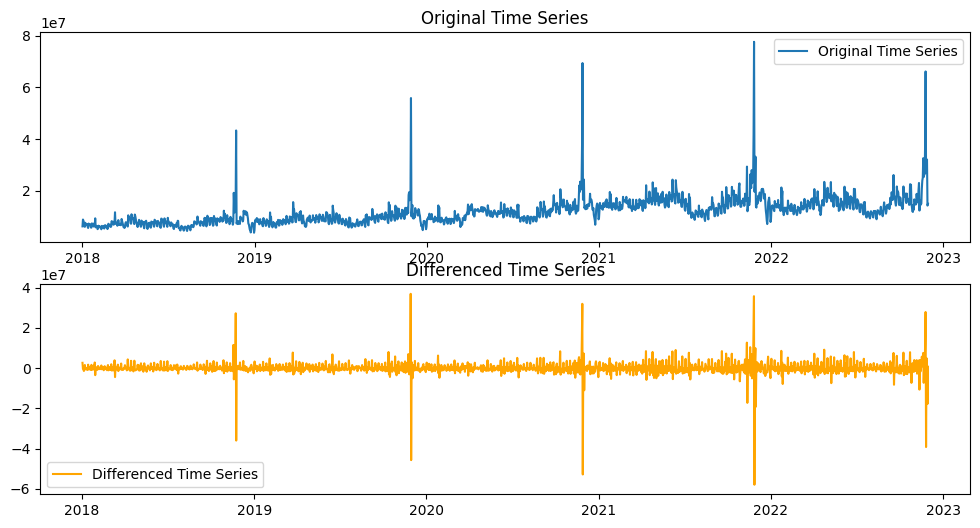

In [23]:
# Plotting the original and differenced time series
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(df.y, label='Original Time Series')
plt.title('Original Time Series')
plt.legend()

plt.subplot(2,1,2)
plt.plot(df.y_diff, label='Differenced Time Series', color='orange')
plt.title('Differenced Time Series')
plt.legend()

In [24]:
result = adfuller(df['y_diff'].dropna())

print('p-value: %f' % result[1])

# Interpreting the ADF test results
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

p-value: 0.000000
The time series is stationary.


# ARIMA Model

In [53]:
# Split the data into train and test sets

test_days = 30
train = df[:-test_days]
test = df[-test_days:]
test.tail()

,y,discount_rate,coupon_rate,y_diff
date,,,,
2022-11-26,26934947.0,30.41,0.38,-39180777.0
2022-11-27,31890868.0,29.75,0.35,4955921.0
2022-11-28,32100918.0,25.27,8.93,210050.0
2022-11-29,14314613.0,19.54,0.26,-17786305.0
2022-11-30,15026662.0,17.10,0.32,712049.0


In [29]:
# using pmdarima for the arima model and the best parameters
model = auto_arima(train['y'], seasonal = False)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1765
Model:               SARIMAX(5, 1, 2)   Log Likelihood              -28817.267
Date:                Fri, 06 Mar 2026   AIC                          57650.535
Time:                        16:19:20   BIC                          57694.337
Sample:                    01-01-2018   HQIC                         57666.720
                         - 10-31-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4136      0.120     -3.449      0.001      -0.649      -0.179
ar.L2          0.3017      0.053      5.671      0.000       0.197       0.406
ar.L3          0.1570      0.028      5.705      0.000       0.103       0.211
ar.L4          0.0679      0.029      2.365      0.018       0.012       0.124
ar.L5          0.0466      0.024      1.937      0.053      -0.001       0.094
ma.L1         -0.1598      0.118     -1.354      0.176      -0.391       0.071
ma.L2         -0.7423      0.108     -6.872      0.000      -0.954      -0.531
sigma2      9.084e+12   1.86e-14   4.88e+26      0.000    9.08e+12    9.08e+12
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            580903.26
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               3.04   Skew:                             5.15
Prob(H) (two-sided):                  0.00   Kurtosis:                        91.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.23e+42. Standard errors may be unstable.
"""

In [30]:
# Predictions
predictions_arima = model.predict(n_periods = len(test))
predictions_arima

2022-11-01    1.445299e+07
2022-11-02    1.474103e+07
2022-11-03    1.503283e+07
2022-11-04    1.527520e+07
2022-11-05    1.534078e+07
2022-11-06    1.553442e+07
2022-11-07    1.554542e+07
2022-11-08    1.563967e+07
2022-11-09    1.565016e+07
2022-11-10    1.569221e+07
2022-11-11    1.570256e+07
2022-11-12    1.571953e+07
2022-11-13    1.572734e+07
2022-11-14    1.573420e+07
2022-11-15    1.573904e+07
2022-11-16    1.574197e+07
2022-11-17    1.574462e+07
2022-11-18    1.574600e+07
2022-11-19    1.574734e+07
2022-11-20    1.574804e+07
2022-11-21    1.574869e+07
2022-11-22    1.574906e+07
2022-11-23    1.574937e+07
2022-11-24    1.574956e+07
2022-11-25    1.574971e+07
2022-11-26    1.574981e+07
2022-11-27    1.574988e+07
2022-11-28    1.574994e+07
2022-11-29    1.574997e+07
2022-11-30    1.575000e+07
Freq: D, dtype: float64

In [36]:
# Function to assess model and visualize output
def model_assessment(train, test, predictions, chart_title):
  # Plot training, test, and forecasts
  plt.figure(figsize = (10,4))
  plt.plot(train, label = 'Train')
  plt.plot(test, label = 'Test')
  plt.plot(predictions, label = "Forecast")
  plt.title(f"Train, Test and Predictions with {chart_title}")
  plt.legend()
  plt.show()
  # Calculating the MAE, RMSE, and MAPE
  mae = mean_absolute_error(test, predictions)
  mse = mean_squared_error(test, predictions)
  rmse = np.sqrt(mse)
  mape = mean_absolute_percentage_error(test, predictions)

  # print the metrics value
  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {100 * mape:.2f} %")


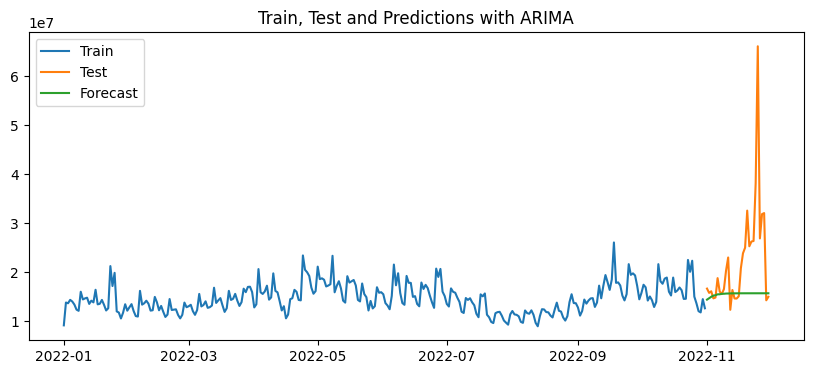

The MAE is 7267306.02
The RMSE is 12366038.30
The MAPE is 24.15 %


In [37]:
# Model assesment
model_assessment(train['y']['2022':], test['y'], predictions_arima, "ARIMA")

# SARIMA

In [38]:
# using pmdarima for the sarima model and the best parameters
model_sarima = auto_arima(train['y'], m = 7)
model_sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                 1765
Model:             SARIMAX(3, 1, 2)x(2, 0, 2, 7)   Log Likelihood              -28762.051
Date:                           Fri, 06 Mar 2026   AIC                          57546.103
Time:                                   19:56:03   BIC                          57606.331
Sample:                               01-01-2018   HQIC                         57568.358
                                    - 10-31-2022                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1.007e+04   4682.845      2.150      0.032     890.110    1.92e+04
ar.L1         -0.3476      0.072     -4.796      0.000      -0.490      -0.206
ar.L2          0.1856      0.032      5.721      0.000       0.122       0.249
ar.L3          0.1034      0.016      6.523      0.000       0.072       0.135
ma.L1         -0.1959      0.074     -2.656      0.008      -0.340      -0.051
ma.L2         -0.5684      0.060     -9.397      0.000      -0.687      -0.450
ar.S.L7        0.0805      0.181      0.445      0.656      -0.274       0.435
ar.S.L14       0.8713      0.172      5.069      0.000       0.534       1.208
ma.S.L7       -0.0035      0.176     -0.020      0.984      -0.349       0.342
ma.S.L14      -0.8322      0.157     -5.308      0.000      -1.139      -0.525
sigma2      9.294e+12      0.000   8.85e+16      0.000    9.29e+12    9.29e+12
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):            848680.41
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               2.85   Skew:                             5.24
Prob(H) (two-sided):                  0.00   Kurtosis:                       109.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 7.15e+31. Standard errors may be unstable.
"""

In [39]:
# Predictions
predictions_sarima = model_sarima.predict(n_periods = len(test))
predictions_sarima

2022-11-01    1.513405e+07
2022-11-02    1.504532e+07
2022-11-03    1.464450e+07
2022-11-04    1.382172e+07
2022-11-05    1.397989e+07
2022-11-06    1.697862e+07
2022-11-07    1.583309e+07
2022-11-08    1.605213e+07
2022-11-09    1.575795e+07
2022-11-10    1.523579e+07
2022-11-11    1.428013e+07
2022-11-12    1.448972e+07
2022-11-13    1.761293e+07
2022-11-14    1.658418e+07
2022-11-15    1.682754e+07
2022-11-16    1.635481e+07
2022-11-17    1.582110e+07
2022-11-18    1.482089e+07
2022-11-19    1.499249e+07
2022-11-20    1.780777e+07
2022-11-21    1.673573e+07
2022-11-22    1.694584e+07
2022-11-23    1.665824e+07
2022-11-24    1.616890e+07
2022-11-25    1.526405e+07
2022-11-26    1.546994e+07
2022-11-27    1.842696e+07
2022-11-28    1.745381e+07
2022-11-29    1.769222e+07
2022-11-30    1.726669e+07
Freq: D, dtype: float64

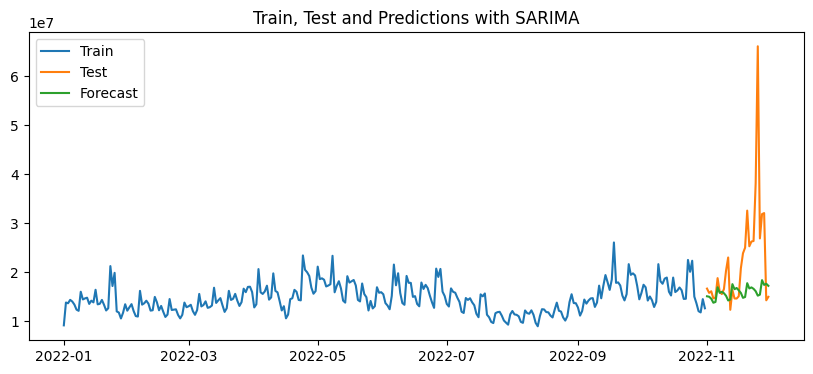

The MAE is 7210571.84
The RMSE is 12152420.83
The MAPE is 24.54 %


In [40]:
# Model assesment
model_assessment(train['y']['2022':], test['y'], predictions_sarima, "SARIMA")

# SARIMAX

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Freq: D
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   y              1795 non-null   float64
 1   discount_rate  1795 non-null   float64
 2   coupon_rate    1795 non-null   float64
 3   y_diff         1794 non-null   float64
dtypes: float64(4)
memory usage: 70.1 KB


In [49]:
df.head()

,y,discount_rate,coupon_rate,y_diff
date,,,,
2018-01-01,6270839.0,34.27,1.09,NaN
2018-01-02,8922076.0,30.87,1.08,2651237.0
2018-01-03,8446101.0,28.11,1.01,-475975.0
2018-01-04,7785798.0,27.32,0.96,-660303.0
2018-01-05,6375303.0,25.70,0.90,-1410495.0


In [54]:
# Split the regressor data into train and test sets
test_days = 30
exog_train = df.iloc[:-test_days, 1:3]
exog_test = df.iloc[-test_days:, 1:3]
exog_test.tail()

,discount_rate,coupon_rate
date,,
2022-11-26,30.41,0.38
2022-11-27,29.75,0.35
2022-11-28,25.27,8.93
2022-11-29,19.54,0.26
2022-11-30,17.10,0.32


In [55]:
# using pmdarima for the sarima model and the best parameters
model_sarimax = auto_arima(train['y'], m = 7, X= exog_train)
model_sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                 1765
Model:             SARIMAX(2, 1, 2)x(2, 0, 2, 7)   Log Likelihood              -28613.022
Date:                           Fri, 06 Mar 2026   AIC                          57250.045
Time:                                   22:16:39   BIC                          57315.749
Sample:                               01-01-2018   HQIC                         57274.324
                                    - 10-31-2022                                         
Covariance Type:                             opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept      1.641e+04   7882.712      2.082      0.037     960.888    3.19e+04
discount_rate   4.03e+05   2.35e+04     17.138      0.000    3.57e+05    4.49e+05
coupon_rate    9.229e+05    6.1e+04     15.138      0.000    8.03e+05    1.04e+06
ar.L1            -0.6527      0.155     -4.202      0.000      -0.957      -0.348
ar.L2             0.1828      0.048      3.771      0.000       0.088       0.278
ma.L1             0.1068      0.155      0.691      0.490      -0.196       0.410
ma.L2            -0.6924      0.124     -5.573      0.000      -0.936      -0.449
ar.S.L7           0.0524      0.187      0.280      0.779      -0.314       0.419
ar.S.L14          0.8998      0.178      5.063      0.000       0.552       1.248
ma.S.L7           0.0181      0.183      0.099      0.921      -0.340       0.376
ma.S.L14         -0.8500      0.161     -5.288      0.000      -1.165      -0.535
sigma2         7.655e+12      0.016   4.79e+14      0.000    7.65e+12    7.65e+12
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):           1075170.50
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               2.05   Skew:                             5.53
Prob(H) (two-sided):                  0.00   Kurtosis:                       123.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.3e+33. Standard errors may be unstable.
"""

In [56]:
# Predictions
predictions_sarimax = model_sarimax.predict(n_periods = len(exog_test), X = exog_test)
predictions_sarimax

2022-11-01    1.675224e+07
2022-11-02    1.494554e+07
2022-11-03    1.488434e+07
2022-11-04    1.296414e+07
2022-11-05    1.205473e+07
2022-11-06    1.394959e+07
2022-11-07    1.341715e+07
2022-11-08    1.328236e+07
2022-11-09    1.441170e+07
2022-11-10    2.077581e+07
2022-11-11    2.121857e+07
2022-11-12    1.346325e+07
2022-11-13    1.489120e+07
2022-11-14    1.299929e+07
2022-11-15    1.348087e+07
2022-11-16    1.398043e+07
2022-11-17    1.803906e+07
2022-11-18    1.675112e+07
2022-11-19    1.712324e+07
2022-11-20    1.980773e+07
2022-11-21    1.847892e+07
2022-11-22    1.908218e+07
2022-11-23    1.913622e+07
2022-11-24    2.068909e+07
2022-11-25    1.926301e+07
2022-11-26    1.851277e+07
2022-11-27    2.073241e+07
2022-11-28    2.607987e+07
2022-11-29    1.588281e+07
2022-11-30    1.479948e+07
Freq: D, dtype: float64

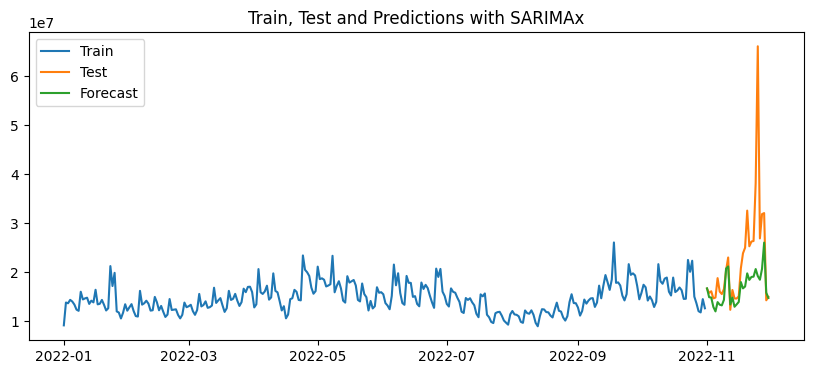

The MAE is 5716550.97
The RMSE is 10394587.06
The MAPE is 19.36 %


In [57]:
# Model assesment
model_assessment(train['y']['2022':], test['y'], predictions_sarimax, "SARIMAx")

# Cross Validation

In [58]:
# define the model to to CV
model_cv = ARIMA(order = (2,1,2), seasonal_order = (2,0,2,7))

In [59]:
# Set the CV rules
cv = model_selection.RollingForecastCV(h = 30, step = 15, initial = df.shape[0]-180)

In [61]:
# Inputs for the CV
cv_score = model_selection.cross_val_score(model_cv, y = df['y'],X = df.iloc[:,1:3],scoring = 'mean_squared_error', cv = cv, verbose = 1,error_score = 'raise')

c:\Users\msi\anaconda3\envs\time_series\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\msi\anaconda3\envs\time_series\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\msi\anaconda3\envs\time_series\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\msi\anaconda3\envs\time_series\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible s

In [65]:
# CV performance
rmse = np.sqrt(np.average(cv_score))
print(f" the RMSE is {int(rmse)}")

 the RMSE is 4405898


# Parameter Tuning

In [68]:
# Defining the parameter grid
param_grid = {'p':[1,2,3], 'd':[0,1], 'q':[1,2,3], 'P':[1,2], 'D':[0], 'Q':[1,2]}
grid = ParameterGrid(param_grid)
len(list(grid))

72

In [ ]:
rmse_list = []

for params in grid:
    model_cv = ARIMA(order=(params['p'], params['d'], params['q']), 
                     seasonal_order=(params['P'], params['D'], params['Q'], 7))

    cv = model_selection.RollingForecastCV(h=30, step=15, initial=df.shape[0]-180)
    
    cv_score = model_selection.cross_val_score(model_cv, y=df['y'],
                                                X=df.iloc[:,1:3],
                                                scoring='mean_squared_error', 
                                                cv=cv, verbose=0,
                                                error_score='raise')
    rmse_list.append(np.sqrt(np.average(cv_score)))  # ✅ only here

In [76]:
# Checking the results
tuning_results = pd.DataFrame(list(grid))
tuning_results['RMSE'] = rmse_list
tuning_results

,D,P,Q,d,p,q,RMSE
0,0,1,1,0,1,1,4.062626e+06
1,0,1,1,0,1,2,4.045199e+06
2,0,1,1,0,1,3,4.044960e+06
3,0,1,1,0,2,1,4.059187e+06
4,0,1,1,0,2,2,4.057299e+06
...,...,...,...,...,...,...,...
67,0,2,2,1,2,2,4.405898e+06
68,0,2,2,1,2,3,4.364967e+06
69,0,2,2,1,3,1,4.413268e+06
70,0,2,2,1,3,2,4.401149e+06


In [79]:
# saveethe best parameters

best_params = tuning_results[tuning_results['RMSE'] == tuning_results['RMSE'].min()].transpose()
best_params

,37
D,0.000000e+00
P,2.000000e+00
Q,1.000000e+00
d,0.000000e+00
p,1.000000e+00
q,2.000000e+00
RMSE,4.014444e+06


# Predicting the future

In [80]:
# Prepare data inputs
y = df['y']
X = df.iloc[:,1:3]

In [ ]:
# fetch the best parameters
p = int(best_params.loc['p'])
d = int(best_params.loc['d'])
q = int(best_params.loc['q'])
P = int(best_params.loc['P'])
D = int(best_params.loc['D'])
Q = int(best_params.loc['Q'])

In [83]:
df_future = pd.read_csv('../ARIMA,SARIMA,SARIMAX/future_regressors.csv', index_col = 'date', parse_dates = True, dayfirst = True)
df_future.head()

,revenue,discount_rate,coupon_rate,discount_rate_lag1,coupon_rate_lag1
date,,,,,
2022-12-01,NaN,0.1831,0.0031,0.1710,0.0032
2022-12-02,NaN,0.1995,0.0036,0.1831,0.0031
2022-12-03,NaN,0.2029,0.0032,0.1995,0.0036
2022-12-04,NaN,0.1898,0.0030,0.2029,0.0032
2022-12-05,NaN,0.1810,0.0042,0.1898,0.0030


In [84]:
# Prepare the Regressors
X_future = df_future.iloc[:,1:3]*100

In [86]:
# Tuned sarimax model
tuned_model = ARIMA(order=(p, d, q), seasonal_order=(P, D, Q, 7)).fit(y=y, X=X)
tuned_model.fit(y, X= X)

,order,"(1, ...)"
,seasonal_order,"(2, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,False
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,None
,trend,None
,with_intercept,True


In [87]:
# Forecasting
predictions = tuned_model.predict(n_periods = len(X_future), X = X_future)

In [89]:
# function to plot the future
def plot_future(y, forecast, title):
    # plot training and forecast
    plt.figure(figsize=(12,6))
    plt.plot(y, label='Train')
    plt.plot(forecast, label='Forecast', color='orange')
    plt.title(title)
    plt.legend()
    plt.show()

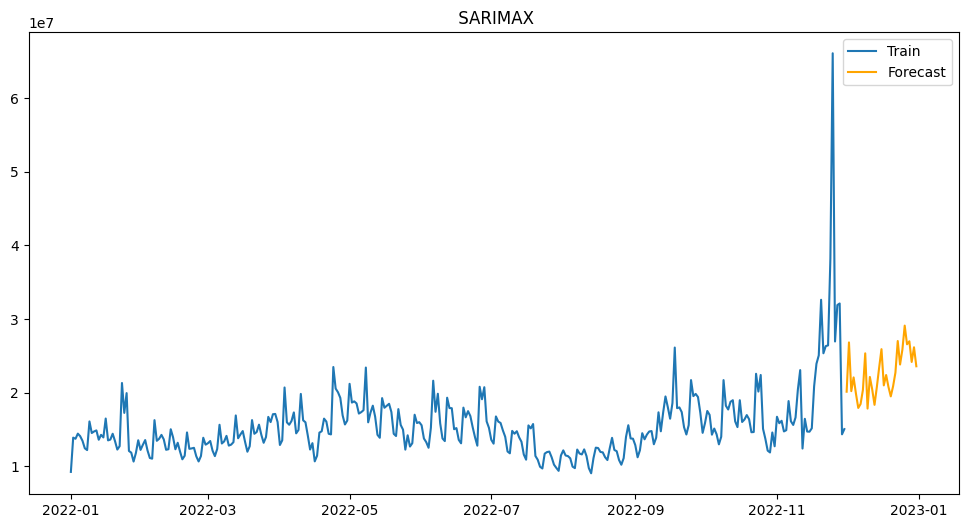

In [92]:
# data visulization
plot_future(y['2022':], predictions, " SARIMAX")